In [1]:
# Imports

import sys
sys.path.append('..')

import torch
from src.model import SiameseUNet

In [2]:
# Instantiate and inspect

model = SiameseUNet()
print(f"Total parameters: {model.count_parameters():,}")
print(f"\nEncoder and decoder share weights: {model.encoder is model.encoder}")  # sanity
print(f"\nModel:\n{model}")

Total parameters: 31,384,833

Encoder and decoder share weights: True

Model:
SiameseUNet(
  (encoder): Encoder(
    (enc1): ConvBlock(
      (conv): Sequential(
        (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
      )
    )
    (enc2): ConvBlock(
      (conv): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(128, eps

In [3]:
# Forward pass w/ dummy data

batch_size = 2
a = torch.randn(batch_size, 3, 256, 256)
b = torch.randn(batch_size, 3, 256, 256)

out = model(a, b)
print(f"Input shape:  {a.shape}")
print(f"Output shape: {out.shape}")
print(f"Output dtype: {out.dtype}")
print(f"Output range: [{out.min().item():.3f}, {out.max().item():.3f}]")
print(f"Contains NaN: {torch.isnan(out).any().item()}")

Input shape:  torch.Size([2, 3, 256, 256])
Output shape: torch.Size([2, 1, 256, 256])
Output dtype: torch.float32
Output range: [-1.315, 1.646]
Contains NaN: False


In [4]:
# Check for logit output

print(f"Min: {out.min().item():.3f}")
print(f"Max: {out.max().item():.3f}")
print(f"Has values outside [0,1]: {(out < 0).any().item() or (out > 1).any().item()}")

probs = torch.sigmoid(out)
print(f"\nAfter sigmoid: [{probs.min().item():.3f}, {probs.max().item():.3f}]")

Min: -1.315
Max: 1.646
Has values outside [0,1]: True

After sigmoid: [0.212, 0.838]


In [5]:
# Verify gradients

loss = out.mean()
loss.backward()

no_grad = [name for name, p in model.named_parameters() if p.grad is None]
print(f"Parameters without gradients: {len(no_grad)}")
if no_grad:
    print(no_grad)
else:
    print("All parameters received gradients.")

Parameters without gradients: 0
All parameters received gradients.


In [6]:
# Verify encoder weights

model.eval()
with torch.no_grad():
    x = torch.randn(1, 3, 256, 256)
    feats_1 = model.encoder(x)
    feats_2 = model.encoder(x)

    for i, (f1, f2) in enumerate(zip(feats_1, feats_2)):
        diff = (f1 - f2).abs().max().item()
        print(f"Encoder level {i}: max difference = {diff}")

Encoder level 0: max difference = 0.0
Encoder level 1: max difference = 0.0
Encoder level 2: max difference = 0.0
Encoder level 3: max difference = 0.0
Encoder level 4: max difference = 0.0


In [11]:
# Test w/ real data

from src.dataset import LEVIRCDDataset

val_ds = LEVIRCDDataset(root="../data/patches/train", augment=False)
sample = val_ds[0]

a = sample["A"].unsqueeze(0)
b = sample["B"].unsqueeze(0)

model.eval()
with torch.no_grad():
    logits = model(a, b)
    pred = torch.sigmoid(logits)

print(f"Prediction shape: {pred.shape}")
print(f"Prediction range: [{pred.min().item():.3f}, {pred.max().item():.3f}]")
print(f"Ground truth change ratio: {sample['mask'].mean().item():.4f}")

Loaded 7120 samples from ../data/patches/train with augment=False
Prediction shape: torch.Size([1, 1, 256, 256])
Prediction range: [0.497, 0.511]
Ground truth change ratio: 0.0873


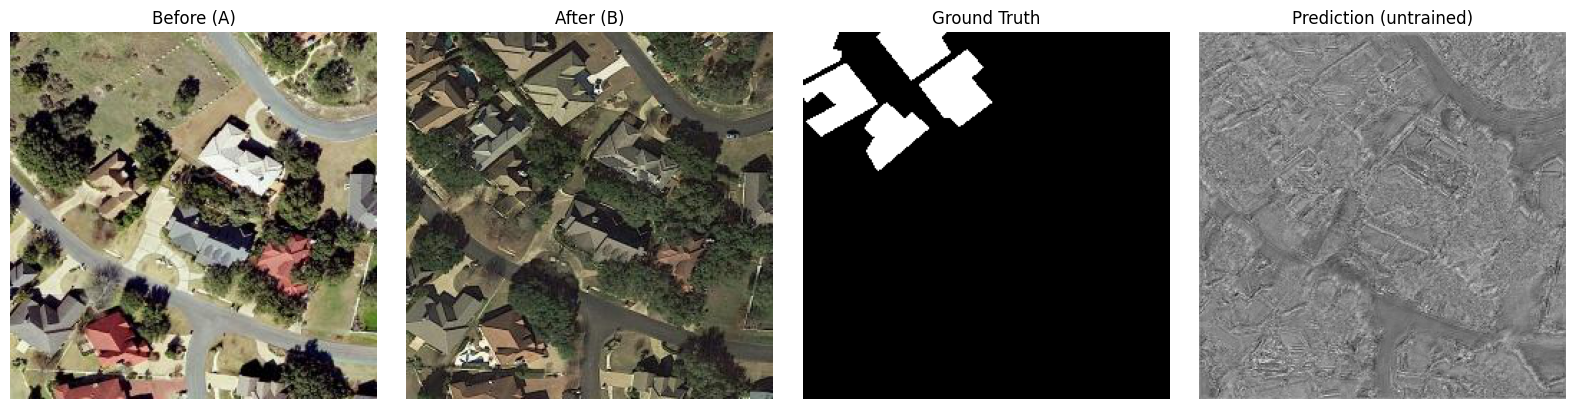

In [12]:
# Visualize untrained prediction vs ground truth

import matplotlib.pyplot as plt
import numpy as np
from src.dataset import IMAGENET_MEAN, IMAGENET_STD

def denormalize(tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(denormalize(sample["A"]))
axes[0].set_title("Before (A)")
axes[1].imshow(denormalize(sample["B"]))
axes[1].set_title("After (B)")
axes[2].imshow(sample["mask"].squeeze(), cmap="gray")
axes[2].set_title("Ground Truth")
axes[3].imshow(pred.squeeze().numpy(), cmap="gray")
axes[3].set_title("Prediction (untrained)")

for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()